In [1]:
import os
import nibabel as nib
import numpy as np
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from glob import glob

In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA version PyTorch was built with:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())

Torch version: 2.7.1+cu118
CUDA version PyTorch was built with: 11.8
Is CUDA available: True


In [8]:
BASE_DIR = '/DATA/puneet_files/BraTS_Dataset/BraTS2023/Training/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/'

count = len([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith('BraTS-GLI-')
])

print(f"Number of directories starting with 'BraTS-GLI-': {count}")

Number of directories starting with 'BraTS-GLI-': 1251


In [9]:
BASE_DIR = '/DATA/puneet_files/BraTS_Dataset/BraTS2023/Training/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/'

all_patients = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith('BraTS-GLI-')
])

train_patients = all_patients[:100]
test_patients = all_patients[:5]

In [47]:
test_patients

['BraTS-GLI-00000-000',
 'BraTS-GLI-00002-000',
 'BraTS-GLI-00003-000',
 'BraTS-GLI-00005-000',
 'BraTS-GLI-00006-000']

In [17]:
class BraTSDataset(Dataset):
    def __init__(self, patient_ids, slice_count=10, augment=False):
        self.data = []
        self.augment = augment
        self.transform = transforms.Compose([transforms.ToTensor()])
        for pid in patient_ids:
            folder = os.path.join(BASE_DIR, pid)
            modalities = ['t1n', 't1c', 't2w', 't2f']
            images = [nib.load(os.path.join(folder, f"{pid}-{m}.nii.gz")).get_fdata() for m in modalities]
            mask = nib.load(os.path.join(folder, f"{pid}-seg.nii.gz")).get_fdata()

            for i in range(images[0].shape[2]):
                x = np.stack([img[:, :, i] for img in images], axis=0).astype(np.float32)
                x = (x - x.mean()) / (x.std() + 1e-5)
                y = (mask[:, :, i] > 0).astype(np.float32)[np.newaxis, ...]
                if np.sum(y) > 0:
                    self.data.append((x, y))
                    if len(self.data) >= slice_count * len(patient_ids):
                        break

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x), torch.tensor(y)

In [3]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def conv(in_c, out_c): return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.down1 = conv(4, 32)
        self.down2 = conv(32, 64)
        self.down3 = conv(64, 128)
        self.middle = conv(128, 256)
        self.up3 = conv(256 + 128, 128)
        self.up2 = conv(128 + 64, 64)
        self.up1 = conv(64 + 32, 32)
        self.out = nn.Conv2d(32, 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        xm = self.middle(self.pool(x3))
        x = F.interpolate(xm, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up3(torch.cat([x, x3], dim=1))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up2(torch.cat([x, x2], dim=1))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up1(torch.cat([x, x1], dim=1))
        return torch.sigmoid(self.out(x))

In [4]:
import random

def train_model(model, loader, epochs=5):
    # Set random seed for reproducibility
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    np.random.seed(42)
    random.seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Loss = {total_loss / len(loader):.4f}")
    return model

In [5]:
def visualize_prediction(model, patient_id, slice_index=80):
    import matplotlib.pyplot as plt
    import nibabel as nib
    import torch
    import numpy as np
    import os

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    folder = os.path.join(BASE_DIR, patient_id)
    modalities = ['t1n', 't1c', 't2w', 't2f']

    images = [nib.load(os.path.join(folder, f"{patient_id}-{mod}.nii.gz")).get_fdata() for mod in modalities]
    mask = nib.load(os.path.join(folder, f"{patient_id}-seg.nii.gz")).get_fdata()

    x = np.stack([img[:, :, slice_index] for img in images], axis=0).astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-5)

    x_tensor = torch.tensor(x).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x_tensor).cpu().squeeze().numpy()

    pred_mask = (pred > 0.05).astype(np.uint8)

    gt_mask = (mask[:, :, slice_index] > 0).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(x[0], cmap='gray')
    plt.title('T1n Modality')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(x[0], cmap='gray')
    plt.imshow(gt_mask, cmap='summer', alpha=0.6)
    plt.title('Ground Truth Overlay')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(x[0], cmap='gray')
    plt.imshow(pred_mask, cmap='Reds', alpha=0.6)
    plt.title('Prediction Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [49]:
train_dataset = BraTSDataset(train_patients, slice_count=10)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

In [ ]:
# model = UNet()
# model = train_model(model, train_loader)

Epoch 1: Loss = 0.0570
Epoch 2: Loss = 0.0363
Epoch 3: Loss = 0.0311
Epoch 4: Loss = 0.0281
Epoch 5: Loss = 0.0271


In [ ]:
# torch.save(model.state_dict(), 'D:/BraTS_Dataset/unet_model_v3.pt')

In [6]:
model = UNet()
model.load_state_dict(torch.load('./models/unet_model_v34.pt', map_location=torch.device('cpu'))) 
model.eval()

UNet(
  (down1): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (down3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (middle): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (up3): Sequential(
    (0): Conv2d(384, 128, kernel_s

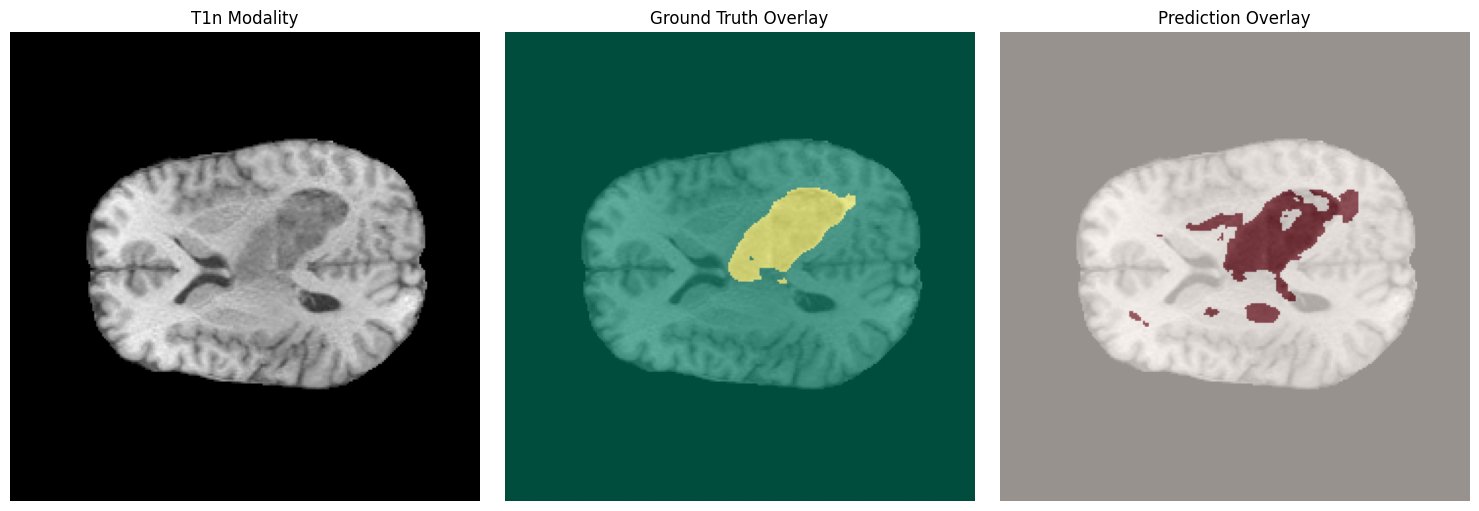

In [13]:
visualize_prediction(model, 'BraTS-GLI-00334-000', slice_index=80)